# Notebook entregable para el reclutamiento de Data Acquisition de UNAM Motorsport

In [ ]:
import pandas as pd

# 1. Cargamos el dataset 
df = pd.read_csv('data.csv')

# 2. Visualizamos las primeras 5 filas para entender la estructura de los datos
print("--- Primeras 5 filas del dataset ---")
display(df.head())

# 3. Revisar información general: nombres de columnas, tipos de datos y conteo de nulos
print("\n--- Información del dataset ---")
df.info()

--- Primeras 5 filas del dataset ---


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,0.00,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted
1,0.01,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted
2,0.02,71.314445,1.000000,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive
3,0.03,86.485997,1.000000,0.221966,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,Aggressive
4,0.04,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,Distracted



--- Información del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         30000 non-null  float64
 1   speed_kmph        30000 non-null  float64
 2   accel_x           30000 non-null  float64
 3   accel_y           30000 non-null  float64
 4   brake_pressure    30000 non-null  float64
 5   steering_angle    30000 non-null  float64
 6   throttle          30000 non-null  float64
 7   lane_deviation    30000 non-null  float64
 8   phone_usage       30000 non-null  int64  
 9   headway_distance  30000 non-null  float64
 10  reaction_time     30000 non-null  float64
 11  behavior_label    30000 non-null  object 
dtypes: float64(10), int64(1), object(1)
memory usage: 2.7+ MB


Una vez vi la estructura de los datos, abrí el .csv y di un repaso rápido al dataset para poder ver si encontraba algún patrón a simplevista.

Detecté un máximo extraño en la aceleración de x, lo cual me hizo preguntarme sobre el comportamiento de los sensores o "entradas" del vector de información. Por lo que mi primer paso será: Comprender el funcionamiento de los sensores; para esto primero haré labor de investigación en los datos y también es probable que contacte a los miembros del equipo para obtener feedback

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Verificación de Timestamps ---
# Calculamos la diferencia de tiempo entre cada fila (delta t)
df['delta_t'] = df['Timestamp'].diff()

# Buscamos saltos que no sean 0.01s (damos un pequeñísimo margen de error por el manejo de decimales en Python), esto debido a la afirmación de que el muestreo es a 100Hz (0.01s)
anomalias_tiempo = df[abs(df['delta_t'] - 0.01) > 0.0001]

print("--- DIAGNÓSTICO DE TIMESTAMPS ---")
if anomalias_tiempo.empty:
    print("El muestreo es continuo. No hay saltos de tiempo (pérdidas de señal) en el reloj.")
else:
    print(f"¡ALERTA! Se detectaron {len(anomalias_tiempo)} saltos de tiempo irregulares.")
    display(anomalias_tiempo[['Timestamp', 'delta_t']].head())

# --- 2. Estadísticas Básicas de los Sensores ---
# Filtramos solo las columnas que nos interesan para el análisis de los sensores, dejé fuera algunas de momento.
columnas_sensores = ['accel_x', 'accel_y', 'brake_pressure', 'throttle']

# Calculamos las métricas solicitadas omitiendo la varianza
estadisticas = pd.DataFrame({
    'Min': df[columnas_sensores].min(),
    'Max': df[columnas_sensores].max(),
    'Media': df[columnas_sensores].mean(),
    'Mediana': df[columnas_sensores].median()
})

print("\n--- ESTADÍSTICAS BÁSICAS ---")
display(estadisticas)

--- DIAGNÓSTICO DE TIMESTAMPS ---
El muestreo es continuo. No hay saltos de tiempo (pérdidas de señal) en el reloj.

--- ESTADÍSTICAS BÁSICAS ---


,Min,Max,Media,Mediana
accel_x,-0.949617,1.000000,0.732958,0.826639
accel_y,-1.532625,2.790790,0.366826,0.288947
brake_pressure,0.003128,99.994365,40.815991,40.005231
throttle,20.001444,99.994762,55.040227,50.146685


Tras revisar los datos, veo varias cosas que me desconciertan. La normalización de las aceleraciones, y el hecho de que throttle siempre esté por arriba de 0, MUY arriba. Las dudas fueron reportadas a Juan y de mi lado seguiré a ver si con el filtrado las cosas cambian

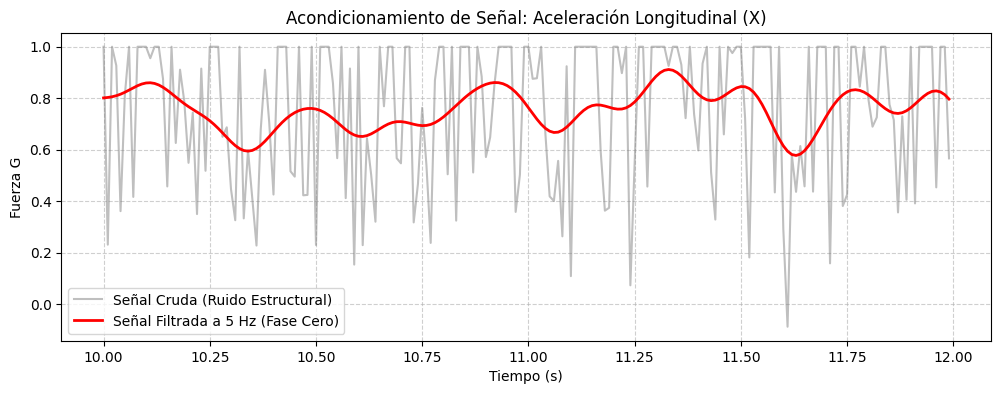

La Fuerza G combinada máxima (filtrada) es: 1.272 G


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Parámetros del filtro
fs = 100.0       # Frecuencia de muestreo en Hz (basado en el delta_t de 0.01)
fc = 5.0         # Frecuencia de corte en Hz
nyq = 0.5 * fs   # Frecuencia de Nyquist (50 Hz)
orden = 4        # Orden del filtro

# 2. Diseño del filtro Butterworth
b, a = butter(orden, fc / nyq, btype='low')

# 3. Aplicación del filtro de fase cero a las aceleraciones (X y Y)
df['accel_x_filt'] = filtfilt(b, a, df['accel_x'])
df['accel_y_filt'] = filtfilt(b, a, df['accel_y'])

# 4. Cálculo de la Fuerza G Combinada (magnitud del vector)
df['G_combinada'] = np.sqrt(df['accel_x_filt']**2 + df['accel_y_filt']**2)

# 5. Visualizar la diferencia (Fragmento de 2 segundos para apreciar el detalle)
plt.figure(figsize=(12, 4))
ventana_inicio, ventana_fin = 1000, 1200 # Ventana de 200 muestras (2 segundos)

plt.plot(df['Timestamp'][ventana_inicio:ventana_fin], df['accel_x'][ventana_inicio:ventana_fin], 
         label='Señal Cruda (Ruido Estructural)', alpha=0.5, color='gray')
plt.plot(df['Timestamp'][ventana_inicio:ventana_fin], df['accel_x_filt'][ventana_inicio:ventana_fin], 
         label='Señal Filtrada a 5 Hz (Fase Cero)', linewidth=2, color='red')

plt.title('Acondicionamiento de Señal: Aceleración Longitudinal (X)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza G')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Imprimir la G combinada máxima requerida en la rúbrica
print(f"La Fuerza G combinada máxima (filtrada) es: {df['G_combinada'].max():.3f} G")